Import Library

The purpose of this step is to systematically initiate the data science workflow. We will import the necessary Python libraries to enable data reading and processing. Moving forward, we will develop the Machine Learning (ML) model, generate graphical visualizations for deeper insights, and perform model tuning to achieve optimal performance. Finally, we will implement MLflow tracking to ensure all experiments are well-documented and organized.

In [1]:
# =========================================
# IMPORT LIBRARIES
# =========================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Handle imbalance dataset
from imblearn.over_sampling import SMOTE

# Machine Learning model
from xgboost import XGBClassifier

# Hyperparameter tuning
import optuna

# MLflow tracking
import mlflow
import mlflow.sklearn

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In this stage, we utilize a suite of essential Python libraries to build a robust fraud detection system. Pandas and Numpy serve as the foundation for reading CSV datasets and handling mathematical or array operations. For data visualization, we rely on Matplotlib and Seaborn to map out data patterns. The core machine learning process is managed by Sklearn, covering everything from preprocessing and data splitting to model evaluation.

Since fraud detection often involves imbalanced datasets, we implement SMOTE to balance the distribution between fraudulent and normal transactions. Our primary model of choice is XGBoost, an industry-standard algorithm known for its high accuracy with tabular data. Finally, we integrate Optuna for automated hyperparameter tuning and utilize MLflow for experiment tracking, allowing us to systematically compare performance across different models.

In [9]:
# =========================================
# LOAD DATASET
# =========================================

# Load training dataset
train_df = pd.read_csv('midterm-machine-learning/train_transaction.csv')

# Load testing dataset
test_df = pd.read_csv('midterm-machine-learning/test_transaction.csv')

# Display first 5 rows
train_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In this code section, the pd.read_csv() function is utilized to read the required dataset files. We define the train_df variable to store the training data, which includes various transaction features along with the isFraud labels. Conversely, the test_df variable is designated for the testing data; it contains transaction features without the isFraud labels, as these are what the model is intended to predict. Finally, the head() function is called to display the first five rows of the dataset, allowing us to inspect the data structure and verify that the files have been successfully loaded.

The purpose of this step is to gain a comprehensive understanding of the dataset's structure. We will examine the dataset's dimensions, the number of available columns, and identify the data types of each variable. Furthermore, this process is crucial for detecting missing values and understanding the characteristics of the isFraud target variable to determine the most effective modeling strategy

In [10]:
# =========================================
# CHECK DATASET SHAPE
# =========================================

print("Train Dataset Shape :", train_df.shape)
print("Test Dataset Shape  :", test_df.shape)

Train Dataset Shape : (590540, 394)
Test Dataset Shape  : (506691, 393)


Utilizing the .shape function provides critical information regarding the dimensions of our datasets. The output reveals that the training dataset has a shape of (590540, 394), while the testing dataset stands at (506691, 393). This indicates that we are processing 590,540 individual transaction records, each encompassing 394 distinct features or columns. The one-column discrepancy between the two sets is due to the testing data excluding the target label, which the model is ultimately designed to predict.

In [11]:
# =========================================
# DATASET INFORMATION
# =========================================

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [12]:
# =========================================
# CHECK MISSING VALUES
# =========================================

missing_values = train_df.isnull().sum()

# Show only columns with missing values
missing_values = missing_values[missing_values > 0]

# Sort descending
missing_values = missing_values.sort_values(ascending=False)

print(missing_values)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
          ...  
V302         12
V303         12
V304         12
V305         12
V306         12
Length: 374, dtype: int64


Checking for missing values is a crucial step since fraud datasets typically contain a significant amount of empty data. This code snippet will identify which columns are incomplete and quantify the number of missing entries within them. Understanding missing values is vital because Machine Learning models generally cannot process null data effectively. Consequently, the results of this check will dictate our next move—whether to fill in those gaps through imputation or to drop specific columns that have excessive missing data.

In [13]:
# =========================================
# CHECK TARGET DISTRIBUTION
# =========================================

print(train_df['isFraud'].value_counts())

isFraud
0    569877
1     20663
Name: count, dtype: int64


In this step, we analyze the isFraud column, which serves as our target variable. The data shows that there are 569,877 normal transactions (labeled 0) compared to only 20,663 fraudulent transactions (labeled 1). This significant disparity where fraud cases are much rarer than normal ones is known as Class Imbalance. Such an imbalance is a common challenge in fraud detection, requiring specific techniques to ensure the model does not become biased toward predicting only normal transactions.

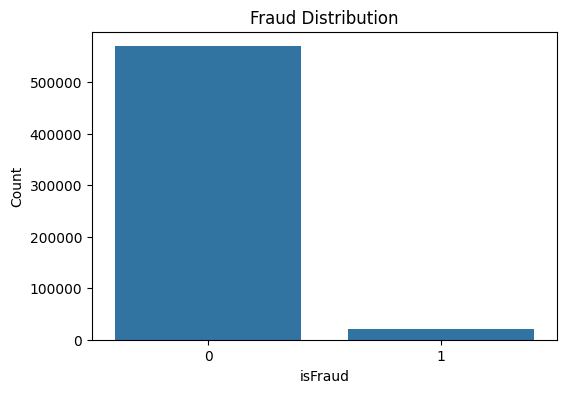

In [14]:
# =========================================
# VISUALIZE FRAUD DISTRIBUTION
# =========================================

plt.figure(figsize=(6,4))

sns.countplot(x='isFraud', data=train_df)

plt.title('Fraud Distribution')
plt.xlabel('isFraud')
plt.ylabel('Count')

plt.show()

This visualization aims to provide a clearer illustration of the target variable's distribution through a graph. The chart will display the comparison between the total number of fraudulent and non-fraudulent transactions side-by-side. In a typical fraud detection scenario, this visualization usually highlights a stark contrast, where the bar representing label 0 (normal transactions) appears significantly high, while the bar for label 1 (fraud) appears very small due to its minimal frequency.

Data Cleaning & Preprocessing

In [15]:
# =========================================
# CALCULATE MISSING VALUE PERCENTAGE
# =========================================

missing_percent = train_df.isnull().mean() * 100

# Show top missing values
missing_percent.sort_values(ascending=False).head(20)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717
dtype: float64

In [16]:
# =========================================
# DROP COLUMNS WITH >90% MISSING VALUES
# =========================================

# Select columns with missing percentage > 90%
cols_to_drop = missing_percent[missing_percent > 90].index

# Drop columns
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

print("Columns dropped:", len(cols_to_drop))

Columns dropped: 2


In [17]:
# =========================================
# SPLIT FEATURES AND TARGET
# =========================================

X = train_df.drop('isFraud', axis=1)

y = train_df['isFraud']

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (590540, 391)
Target Shape  : (590540,)


During the data preparation phase, we split the dataset into two primary components: X and y. The variable X functions as the input, containing all the transactional features that the model will learn from, such as the transaction amount, card type, address, and product information. Meanwhile, the variable y represents the target or output we aim to predict, which is the isFraud label. Mastering the core concept where $X = \text{input}$ and $y = \text{target}$ is essential in Machine Learning to ensure the model correctly learns to map feature patterns to the intended outcome

In [18]:
# =========================================
# CHECK CATEGORICAL COLUMNS
# =========================================

categorical_cols = X.select_dtypes(include=['object']).columns

print("Number of categorical columns :", len(categorical_cols))

print(categorical_cols)

Number of categorical columns : 14
Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='object')


In [19]:
# =========================================
# LABEL ENCODING
# =========================================

le = LabelEncoder()

for col in categorical_cols:
    
    X[col] = X[col].astype(str)
    test_df[col] = test_df[col].astype(str)

    le.fit(list(X[col]) + list(test_df[col]))

    X[col] = le.transform(X[col])
    test_df[col] = le.transform(test_df[col])

print("Label Encoding Completed!")

Label Encoding Completed!


In [20]:
# =========================================
# FILL MISSING VALUES
# =========================================

X = X.fillna(-999)

test_df = test_df.fillna(-999)

print("Missing values handled!")

Missing values handled!


rain Test Split + Handle Imbalance

In [21]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape :", X_train.shape)
print("X_valid shape :", X_valid.shape)

print("y_train shape :", y_train.shape)
print("y_valid shape :", y_valid.shape)

X_train shape : (472432, 391)
X_valid shape : (118108, 391)
y_train shape : (472432,)
y_valid shape : (118108,)


The train_test_split() function is utilized to partition the dataset into two distinct sets: training data and validation data. In this implementation, we set test_size=0.2, meaning that 80% of the data is allocated for model training while the remaining 20% is reserved for validation, following standard Machine Learning practices. Furthermore, the inclusion of the stratify=y parameter is critical due to the imbalanced nature of the fraud dataset. By employing stratification, we ensure that the proportions of fraudulent and non-fraudulent transactions remain consistent and balanced across both the training and validation subsets.

In [22]:
# =========================================
# CHECK CLASS DISTRIBUTION BEFORE SMOTE
# =========================================

print(y_train.value_counts())

isFraud
0    455902
1     16530
Name: count, dtype: int64


In [23]:
# =========================================
# APPLY SMOTE
# =========================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")

print(y_train_smote.value_counts())

After SMOTE
isFraud
0    455902
1    455902
Name: count, dtype: int64


SMOTE (Synthetic Minority Over-sampling Technique) works by generating synthetic fraudulent transaction data to artificially increase the size of the minority class. Before applying SMOTE, the dataset shows a significant imbalance with 455,902 normal transactions compared to only 16,530 fraud cases. Once the SMOTE process is executed, the minority class is over-sampled to match the majority class, resulting in an equal distribution of 455,902 records for both labels. This technique is vital to prevent model bias and ensure the system can better recognize the patterns of fraudulent transactions.

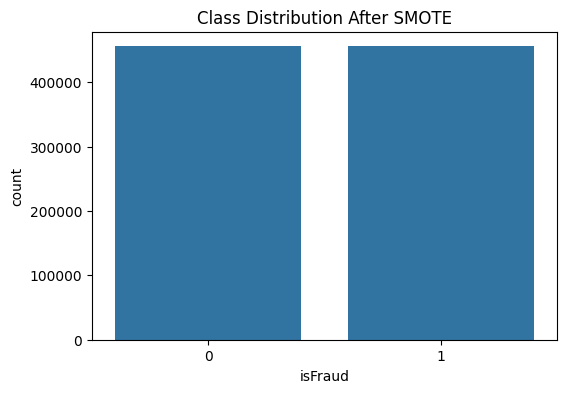

In [24]:
# =========================================
# VISUALIZE AFTER SMOTE
# =========================================

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title('Class Distribution After SMOTE')

plt.show()

Training Machine Learning Model

In [25]:
# =========================================
# TRAIN XGBOOST MODEL
# =========================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Train model
model.fit(X_train_smote, y_train_smote)

print("Model training completed!")

Model training completed!


In this XGBoost model configuration, we utilize several key parameters to control performance and learning speed. The n_estimators=100 parameter defines the number of decision trees to be built; generally, a higher number of trees can enhance accuracy, though it will increase the computation time. We also limit the depth of each tree with max_depth=6 to manage model complexity. Additionally, a learning_rate=0.1 is applied to regulate how quickly the model learns during each iteration, while eval_metric='logloss' is set as the internal evaluation metric to measure the model's performance during the training process.

In [26]:
# =========================================
# PREDICTION
# =========================================

y_pred = model.predict(X_valid)

y_prob = model.predict_proba(X_valid)[:, 1]

print("Prediction completed!")

Prediction completed!


In [27]:
# =========================================
# MODEL EVALUATION
# =========================================

accuracy = accuracy_score(y_valid, y_pred)

precision = precision_score(y_valid, y_pred)

recall = recall_score(y_valid, y_pred)

f1 = f1_score(y_valid, y_pred)

roc_auc = roc_auc_score(y_valid, y_prob)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)
print("ROC AUC   :", roc_auc)

Accuracy  : 0.974040708504081
Precision : 0.721277478224803
Recall    : 0.42075973868860395
F1 Score  : 0.531479217603912
ROC AUC   : 0.8920417546710078


In evaluating model performance, we utilize several key metrics to gain a comprehensive overview. Accuracy measures the overall percentage of correct predictions, while Precision indicates how accurate the model is when it flags a transaction as fraud. However, in fraud detection, Recall is the most critical metric as it measures how many actual fraudulent transactions the model successfully identified. Additionally, we use the F1-Score to balance precision and recall, as well as ROC-AUC, which is a vital metric for this use case. The closer the ROC-AUC score is to 1.0, the better the model's ability to distinguish between normal and fraudulent transactions.

In [28]:
# =========================================
# CLASSIFICATION REPORT
# =========================================

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.72      0.42      0.53      4133

    accuracy                           0.97    118108
   macro avg       0.85      0.71      0.76    118108
weighted avg       0.97      0.97      0.97    118108



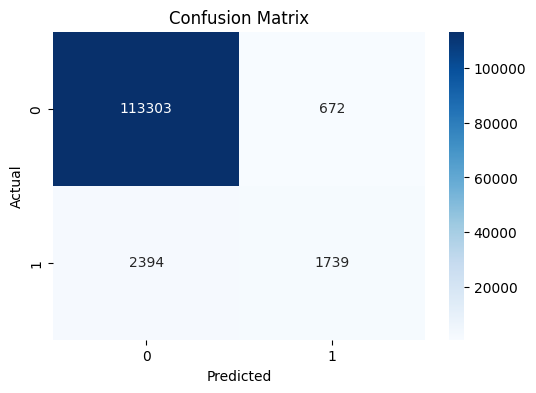

In [29]:
# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

A Confusion Matrix is utilized to break down the model's prediction results into four distinct categories: True Negative (TN), False Positive (FP), False Negative (FN), and True Positive (TP). In the context of fraud detection, our primary focus lies on the False Negative (FN) values. This is considered the most critical metric because it represents instances where actual fraudulent transactions slip through and go undetected by the system. Minimizing FN is essential to mitigate the risk of financial loss resulting from unidentified fraudulent activities

Hyperparameter Tuning dengan Optuna

In [30]:
# =========================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================

def objective(trial):

    # Hyperparameter search space
    params = {
        
        'n_estimators': trial.suggest_int(
            'n_estimators',
            50,
            200
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'random_state': 42,

        'eval_metric': 'logloss'
    }

    # Create model
    model = XGBClassifier(**params)

    # Train model
    model.fit(
        X_train_smote,
        y_train_smote
    )

    # Predict probabilities
    y_prob = model.predict_proba(X_valid)[:, 1]

    # Calculate ROC-AUC
    roc_auc = roc_auc_score(
        y_valid,
        y_prob
    )

    return roc_auc

In the model optimization process, we utilize Optuna to automatically search for the most optimal parameter combinations. The trial.suggest_int() function is employed to determine the best integer values, such as deciding whether a max_depth of 4 or 8 yields better results. Meanwhile, trial.suggest_float() is used to find the most precise decimal values. All of these operations are executed within an Objective Function, where our primary goal is to maximize the ROC-AUC score to ensure the model achieves the highest possible detection accuracy

In [31]:
# =========================================
# RUN OPTUNA TUNING
# =========================================

study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=50
)

print("Best Parameters:")
print(study.best_trial.params)

[I 2026-05-09 10:51:36,001] A new study created in memory with name: no-name-0281665a-a5aa-4df6-89c3-91f632fe814d
[I 2026-05-09 10:52:43,993] Trial 0 finished with value: 0.9101074096554957 and parameters: {'n_estimators': 151, 'max_depth': 8, 'learning_rate': 0.056290658422731954, 'subsample': 0.9858625601917346, 'colsample_bytree': 0.8762960788437713}. Best is trial 0 with value: 0.9101074096554957.
[I 2026-05-09 10:53:14,979] Trial 1 finished with value: 0.9030935212051874 and parameters: {'n_estimators': 97, 'max_depth': 5, 'learning_rate': 0.2988186146192204, 'subsample': 0.6245388397877989, 'colsample_bytree': 0.6725073054828785}. Best is trial 0 with value: 0.9101074096554957.
[I 2026-05-09 10:53:50,586] Trial 2 finished with value: 0.936588583152619 and parameters: {'n_estimators': 83, 'max_depth': 8, 'learning_rate': 0.2557024446726164, 'subsample': 0.9391193871963205, 'colsample_bytree': 0.9873352209228853}. Best is trial 2 with value: 0.936588583152619.
[I 2026-05-09 10:54:2

Best Parameters:
{'n_estimators': 190, 'max_depth': 10, 'learning_rate': 0.2849608591256294, 'subsample': 0.9648004173340741, 'colsample_bytree': 0.6590038779685219}


When running the optimization study, we set the parameter direction='maximize' because our primary objective is to achieve the highest possible ROC-AUC score. We also define n_trials=50, meaning Optuna will automatically experiment with 50 different parameter combinations. It is important to note that this process can be time-consuming; this is perfectly normal since, during each trial, the system must train a new model from scratch and re-evaluate its performance to identify the most optimal configuration.

In [32]:
# =========================================
# SAVE BEST PARAMETERS
# =========================================

best_params = study.best_trial.params

print(best_params)

{'n_estimators': 190, 'max_depth': 10, 'learning_rate': 0.2849608591256294, 'subsample': 0.9648004173340741, 'colsample_bytree': 0.6590038779685219}


In [33]:
# =========================================
# TRAIN BEST MODEL
# =========================================

best_params['random_state'] = 42

best_params['eval_metric'] = 'logloss'

best_model = XGBClassifier(
    **best_params
)

best_model.fit(
    X_train_smote,
    y_train_smote
)

print("Best model trained successfully!")

Best model trained successfully!


In [34]:
# =========================================
# EVALUATE BEST MODEL
# =========================================

y_pred_best = best_model.predict(X_valid)

y_prob_best = best_model.predict_proba(X_valid)[:, 1]

# Metrics
accuracy = accuracy_score(
    y_valid,
    y_pred_best
)

precision = precision_score(
    y_valid,
    y_pred_best
)

recall = recall_score(
    y_valid,
    y_pred_best
)

f1 = f1_score(
    y_valid,
    y_pred_best
)

roc_auc = roc_auc_score(
    y_valid,
    y_prob_best
)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)
print("ROC AUC   :", roc_auc)

Accuracy  : 0.9856317946286449
Precision : 0.9375
Recall    : 0.6315025405274619
F1 Score  : 0.7546624259071852
ROC AUC   : 0.968508822175921


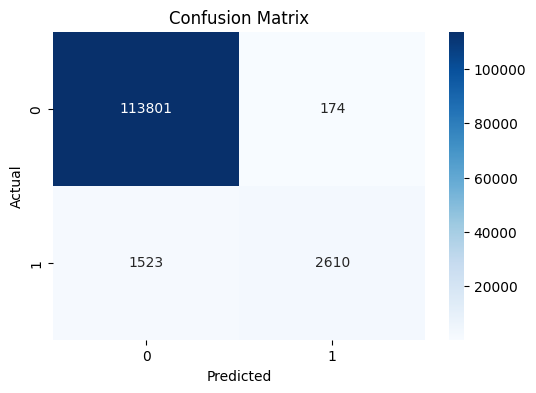

In [35]:
# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(
    y_valid,
    y_pred_best
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

MLflow Tracking

In [37]:
# =========================================
# SET MLFLOW TRACKING URI
# =========================================

import os

# Create mlruns folder
os.makedirs("mlruns", exist_ok=True)

# Set tracking URI
mlflow.set_tracking_uri("file:///C:/Users/erdi jova/midterm-machine-learning/mlruns")

# Set experiment
mlflow.set_experiment(
    "Fraud_Detection_Experiment"
)

print("MLflow experiment created successfully!")

2026/05/09 12:06:05 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_Experiment' does not exist. Creating a new experiment.


MLflow experiment created successfully!


In [38]:
# =========================================
# MLFLOW TRACKING
# =========================================

with mlflow.start_run():

    # Log parameters
    mlflow.log_params(best_params)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_metric("precision", precision)

    mlflow.log_metric("recall", recall)

    mlflow.log_metric("f1_score", f1)

    mlflow.log_metric("roc_auc", roc_auc)

    # Log model
    mlflow.sklearn.log_model(
        best_model,
        "xgboost_model"
    )

    print("MLflow tracking completed!")

2026/05/09 12:06:52 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/05/09 12:06:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

MLflow tracking completed!


In this final stage, we integrate MLflow to systematically document every aspect of the model experiments. The log_params() function is utilized to save parameter configurations such as max_depth, learning_rate, and n_estimators. Simultaneously, we employ log_metric() to record the model's performance evaluation results, including accuracy, recall, and ROC-AUC scores. Finally, the log_model() function saves the fully trained model, ensuring we have a complete track record that allows us to compare or redeploy the best-performing models in the future.

Once the experimentation process is complete, you can monitor the results through a visual interface by launching the MLflow UI. To do this, open a new CMD or Terminal window on your computer and type the command mlflow ui. After the service is successfully running, open your web browser and navigate to [http://127.0.0.1:5000](http://127.0.0.1:5000). Through this dashboard, you can view the entire training history, compare performance across different experiments, and easily analyze which parameters yielded the best fraud detection model.

Predict Test Dataset & Submission CSV

In [42]:
# =========================================
# PREPARE TEST DATA
# =========================================

# Save TransactionID
test_ids = test_df['TransactionID']

# Drop target column if exists
if 'isFraud' in test_df.columns:
    test_df = test_df.drop('isFraud', axis=1)

print("Test data prepared!")

Test data prepared!


In [43]:
# =========================================
# PREDICT TEST DATA
# =========================================

# Save TransactionID
test_ids = test_df['TransactionID']

# Predict fraud probability
test_prob = best_model.predict_proba(test_df)[:, 1]

print("Prediction completed!")

Prediction completed!


In [44]:
# =========================================
# CREATE SUBMISSION DATAFRAME
# =========================================

submission = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': test_prob
})

submission.head()

,TransactionID,isFraud
0,3663549,0.000560
1,3663550,0.000006
2,3663551,0.000114
3,3663552,0.000098
4,3663553,0.000016


In [45]:
# =========================================
# SAVE SUBMISSION CSV
# =========================================

submission.to_csv(
    'submission.csv',
    index=False
)

print("submission.csv saved successfully!")

submission.csv saved successfully!
